# **NETFLIX DATA ANALYSIS**

## **Objective**
The objective of this project is to analyze Netflix's content library using Python and Pandas to identify trends in content type, release years, countries, genres, ratings, and content addition patterns. The insights can help understand Netflix's content strategy.

# **IMPORT LIBRARIES**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# **LOAD THE DATASET**

In [3]:
df=pd.read_csv("/content/netflix_titles_nov_2019.csv")

# **EXPLORE THE DATASET**

## Dataset
## Dataset

- **Dataset Name:** Netflix Titles Dataset
- **Source:** Kaggle (Netflix Movies and TV Shows Dataset)
- **Number of Rows:** 5,837
- **Number of Columns:** 12

### Features

- `show_id` – Unique identifier for each title
- `title` – Name of the movie or TV show
- `director` – Director(s) of the title
- `cast` – Main cast members
- `country` – Country of production
- `date_added` – Date the title was added to Netflix
- `release_year` – Original release year
- `rating` – Content rating (e.g., TV-MA, PG)
- `duration` – Duration (minutes for movies or seasons for TV shows)
- `listed_in` – Genre(s)
- `description` – Brief summary of the title
- `type` – Movie or TV Show

In [96]:
df.head()


,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,Unknown,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,2019-11-30,2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,Unknown,2019-11-30,2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,2019-11-30,2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium",2019-11-29,2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,Unknown,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaT,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [97]:
df.shape

(5837, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [7]:
df.dtypes

,0
show_id,int64
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object
listed_in,object


# **DATA CLEANING**

In [8]:
#missing values
df.isnull().sum()

,0
show_id,0
title,0
director,1901
cast,556
country,427
date_added,642
release_year,0
rating,10
duration,0
listed_in,0


In [10]:
#Duplicate Rows
df.duplicated().sum()

np.int64(0)

### **HANDLE MISSING VALUES**
Although some rows contain multiple missing values, none of the essential columns (title, type, release_year, etc.) are missing. Therefore, no rows were removed.

## **Missing Value Summary**

*   Director → Filled with "Unknown"
*   Cast → Filled with "Unknown"
*   Country → Filled with "Unknown"
*   Rating → Filled with "Unknown"
*   Date Added → Left as missing
*   Duplicate Rows → None

In [11]:
#Handle missing values in Director
#We cannot accurately guess the director from other columns, so calculating or predicting it would introduce incorrect data
df['director'].fillna('Unknown', inplace=True)

In [12]:
df['director'].isnull().sum()


np.int64(0)

In [14]:
#Handle missing values in Cast
df['cast'].fillna('Unknown', inplace=True)

In [15]:
df['cast'].isnull().sum()

np.int64(0)

In [17]:
#Handle missing values in Country
df['country'].fillna('Unknown', inplace=True)

In [18]:
df['country'].isnull().sum()

np.int64(0)

In [19]:
#Handle missing values in date_added
#For a date, "Unknown" turns the column into mixed text/date values, which is not ideal if we later want to work with dates.

In [21]:
#Handle missing values in rating
df['rating'].fillna('Unknown', inplace=True)

In [22]:
df['rating'].isnull().sum()


np.int64(0)

In [23]:
#Handle outliers in release_year
#No unrealistic values were found in the release_year column.
df['release_year'].max()

2020

In [24]:
df['release_year'].min()

1925

In [25]:
#Handle inconsistent data in type
df['type'].unique()

array(['TV Show', 'Movie'], dtype=object)

In [26]:
#Handle inconsistent data in rating
df['rating'].unique()

array(['TV-14', 'TV-G', 'TV-Y', 'TV-MA', 'TV-PG', 'R', 'TV-Y7', 'PG', 'G',
       'PG-13', 'TV-Y7-FV', 'NR', 'UR', 'NC-17', 'Unknown'], dtype=object)

In [27]:
#Handle inconsistent data in country
#Removed trailing commas from entries in the country column
df['country'].unique()

array(['South Korea', 'Unknown', 'India', 'France, Senegal, Belgium',
       'Canada, United Kingdom', 'Nigeria', 'France', 'South Africa',
       'United States, Spain, Colombia, Mexico', 'United States', 'Japan',
       'Brazil', 'Germany, Canada, United States', 'Canada, Norway',
       'Poland', 'Mexico', 'China', 'United States, United Arab Emirates',
       'United States, Japan', 'Spain', 'Singapore, United States',
       'United States, Canada',
       'United Kingdom, Germany, Canada, United States',
       'Australia, France', 'Germany', 'Germany, United Kingdom',
       'Italy, United States',
       'United States, New Zealand, United Kingdom',
       'United Kingdom, Germany, United States', 'United States, Germany',
       'Argentina', 'Taiwan', 'United Kingdom, United States',
       'Finland, Germany, Belgium', 'United Kingdom, France',
       'United States, Spain, Chile, Peru', 'Colombia',
       'United States, Ireland', 'India, United States', 'Thailand',
       'T

In [28]:
df['country']=df['country'].str.rstrip(',')

In [29]:
df['country'].unique()

array(['South Korea', 'Unknown', 'India', 'France, Senegal, Belgium',
       'Canada, United Kingdom', 'Nigeria', 'France', 'South Africa',
       'United States, Spain, Colombia, Mexico', 'United States', 'Japan',
       'Brazil', 'Germany, Canada, United States', 'Canada, Norway',
       'Poland', 'Mexico', 'China', 'United States, United Arab Emirates',
       'United States, Japan', 'Spain', 'Singapore, United States',
       'United States, Canada',
       'United Kingdom, Germany, Canada, United States',
       'Australia, France', 'Germany', 'Germany, United Kingdom',
       'Italy, United States',
       'United States, New Zealand, United Kingdom',
       'United Kingdom, Germany, United States', 'United States, Germany',
       'Argentina', 'Taiwan', 'United Kingdom, United States',
       'Finland, Germany, Belgium', 'United Kingdom, France',
       'United States, Spain, Chile, Peru', 'Colombia',
       'United States, Ireland', 'India, United States', 'Thailand',
       'T

In [30]:
df['date_added']=pd.to_datetime(df['date_added'])

In [31]:
df['date_added'].dtype

dtype('<M8[ns]')

In [92]:
# Remove newline characters from text columns

df = df.replace(r'[\r\n]+', ' ', regex=True)

# **EXPLORATORY DATA ANALYSIS**

In [32]:
#What is the distribution of Movies and TV Shows on Netflix?
type_counts=df['type'].value_counts()
type_counts

,count
type,
Movie,3939
TV Show,1898


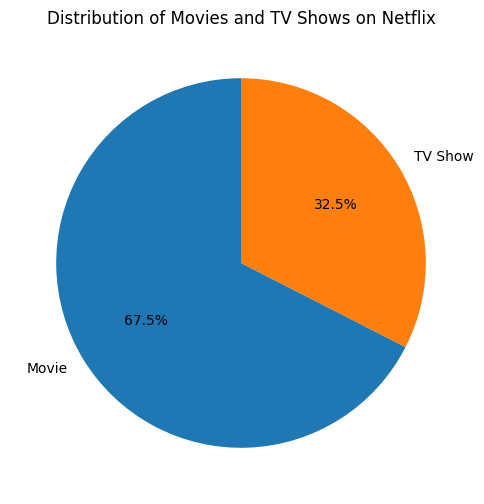

In [33]:
plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index,autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Movies and TV Shows on Netflix")
plt.show()

In [34]:
movie_percent = (type_counts['Movie'] / type_counts.sum()) * 100
tv_percent = (type_counts['TV Show'] / type_counts.sum()) * 100

print(f"Movies account for approximately {movie_percent:.1f}% of the Netflix catalog, while TV Shows account for {tv_percent:.1f}%. This indicates that Netflix's catalog is dominated by Movies.")

Movies account for approximately 67.5% of the Netflix catalog, while TV Shows account for 32.5%. This indicates that Netflix's catalog is dominated by Movies.


In [35]:
# Which countries produce the most Netflix content?
country_counts=df['country'].str.split(",").explode().str.strip().value_counts().sort_values(ascending=False)

country_counts

,count
country,
United States,2421
India,753
United Kingdom,559
Unknown,427
Canada,300
...,...
Cuba,1
Kazakhstan,1
Montenegro,1


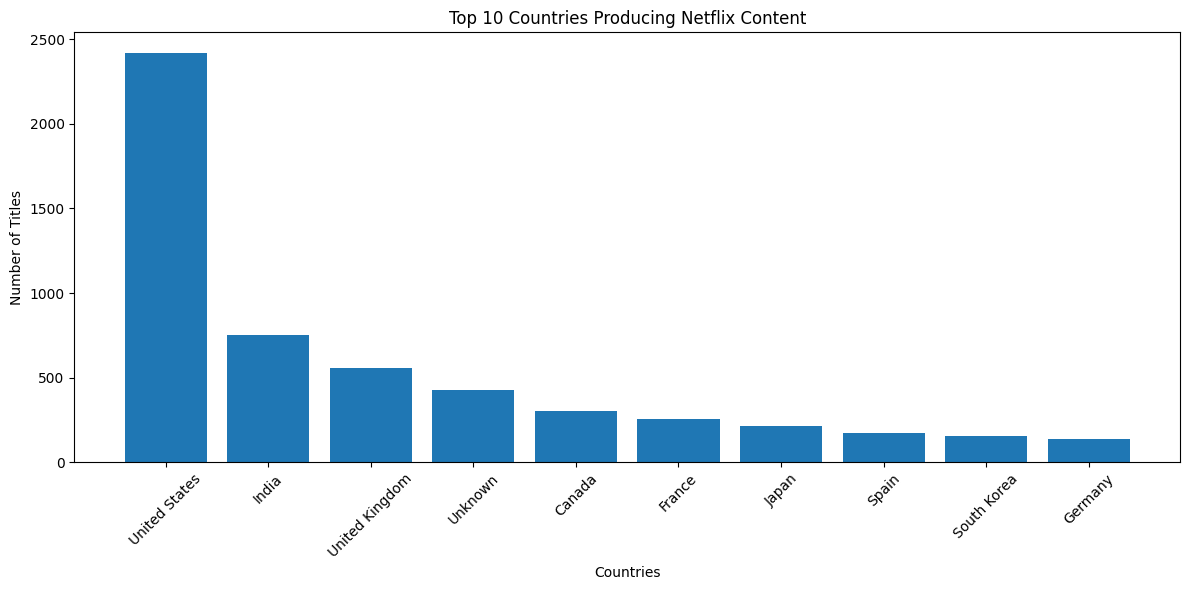

In [36]:
plt.figure(figsize=(12,6))
plt.bar(country_counts.index[:10], country_counts.values[:10])
plt.xlabel("Countries")
plt.ylabel("Number of Titles")
plt.title("Top 10 Countries Producing Netflix Content")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
highest_country=country_counts.index[0]
highest_content=country_counts.max()
print(f"{highest_country} is the country with highest Netfilx Content with total of {highest_content}.")

United States is the country with highest Netfilx Content with total of 2421.


In [38]:
#Which year had the highest number of releases?
year_counts=df['release_year'].value_counts()
year_counts.head(1)

,count
release_year,
2018,1040


In [39]:
h_year=year_counts.index[0]
h_count=year_counts.values[0]
print(f"{h_year} is the year with highest number of releases with the count of {h_count}.")

2018 is the year with highest number of releases with the count of 1040.


In [40]:
# How has Netflix content grown over the years?
year_counts2=year_counts.sort_index(ascending=True)

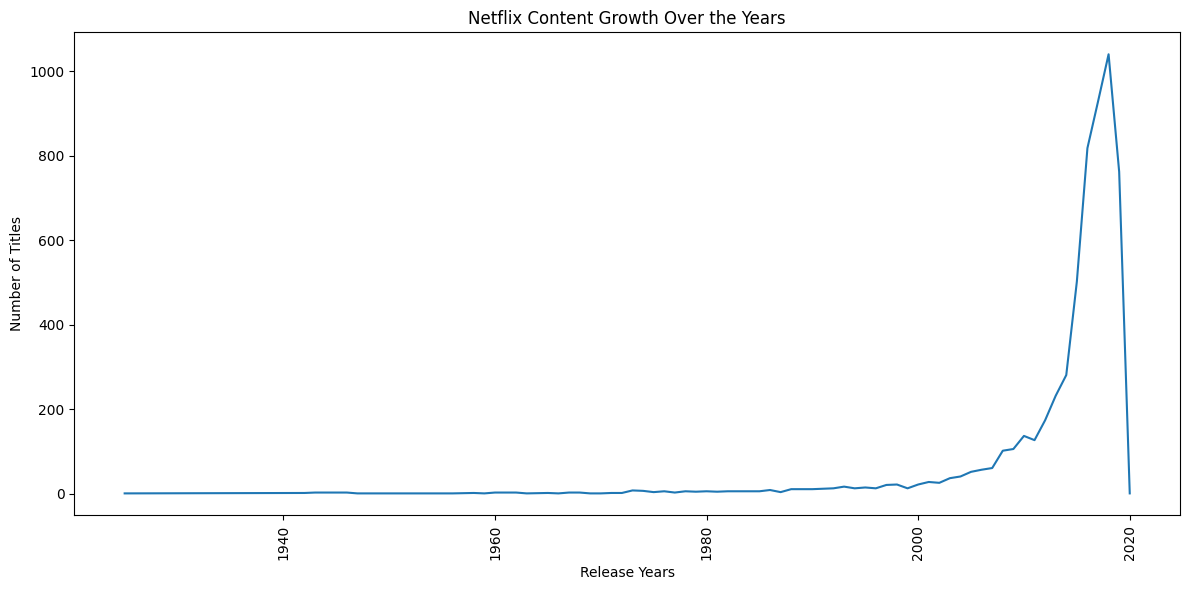

In [41]:
plt.figure(figsize=(12,6))
plt.plot(year_counts2.index, year_counts2.values)
plt.title("Netflix Content Growth Over the Years")
plt.xlabel("Release Years")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [42]:
print("Netflix released very little content in the early years. The number of releases remained low until around 2000.\nAfter 2000, the number of titles increased rapidly, showing significant growth in Netflix's content library over time.")

Netflix released very little content in the early years. The number of releases remained low until around 2000.
After 2000, the number of titles increased rapidly, showing significant growth in Netflix's content library over time.


In [43]:
# Which ratings are most common?
rating_count=df['rating'].value_counts()
rating_count

,count
rating,
TV-MA,1937
TV-14,1593
TV-PG,678
R,439
PG-13,227
NR,218
PG,160
TV-Y7,156
TV-G,147


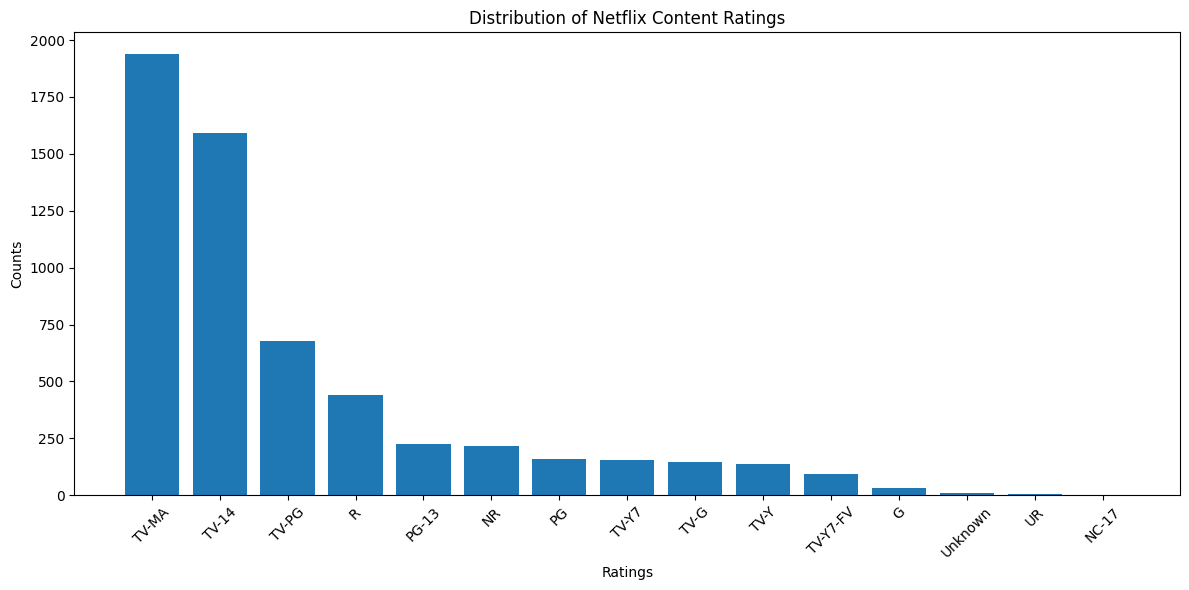

In [44]:
plt.figure(figsize=(12,6))
plt.bar(rating_count.index, rating_count.values)
plt.xlabel("Ratings")
plt.ylabel("Counts")
plt.title("Distribution of Netflix Content Ratings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
highest_rating = rating_count.index[0]
highest_count = rating_count.iloc[0]

print(f"{highest_rating} is the most common Netflix content rating with {highest_count} titles.")

TV-MA is the most common Netflix content rating with 1937 titles.


In [46]:
# Which genres are most common?
genre_counts=df['listed_in'].str.split(",").explode().str.strip().value_counts()
genre_counts

,count
listed_in,
International Movies,1797
Dramas,1488
Comedies,992
International TV Shows,966
Documentaries,658
TV Dramas,574
Action & Adventure,532
Independent Movies,516
TV Comedies,425


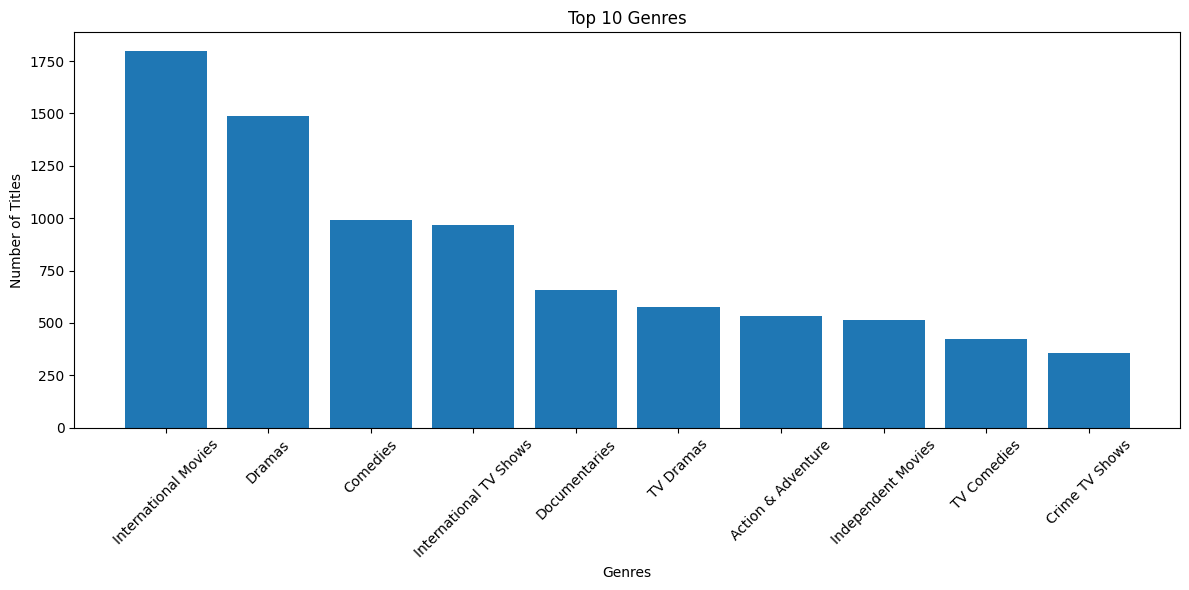

In [47]:
plt.figure(figsize=(12,6))
plt.bar(genre_counts.index[:10], genre_counts.values[:10])
plt.xlabel("Genres")
plt.ylabel("Number of Titles")
plt.title("Top 10 Genres")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
top_genre = genre_counts.index[0]
top_count = genre_counts.iloc[0]

print(f"{top_genre} is the most common genre on Netflix with {top_count} titles.")

International Movies is the most common genre on Netflix with 1797 titles.


In [49]:
# Top 10 directors on Netflix
director_count=df[df['director'] != 'Unknown']['director'].str.split(",").explode().str.strip().value_counts().head(10)
director_count

,count
director,
Jan Suter,21
Raúl Campos,19
Jay Karas,14
Marcus Raboy,14
Jay Chapman,12
Steven Spielberg,8
Martin Scorsese,8
Johnnie To,8
Umesh Mehra,8


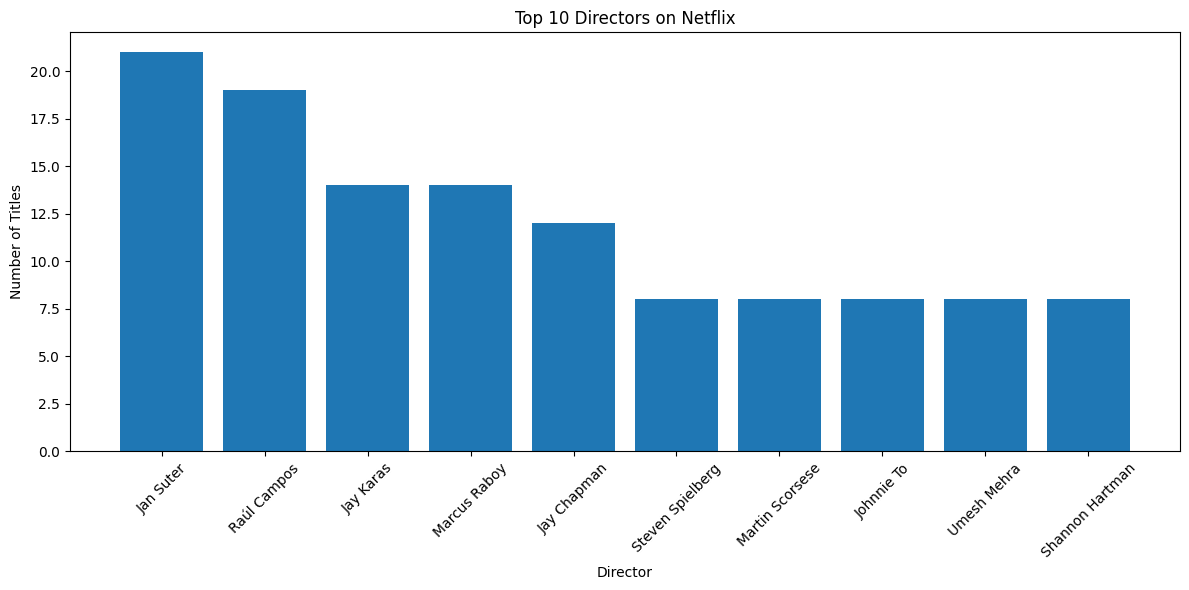

In [50]:
plt.figure(figsize=(12,6))
plt.bar(director_count.index, director_count.values)
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.title("Top 10 Directors on Netflix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
top_director = director_count.index[0]
top_count2 = director_count.iloc[0]

print(f"{top_director} is the director with highest titles of {top_count2} titles.")

Jan Suter is the director with highest titles of 21 titles.


In [52]:
# Actors who appear most frequently
actor_count=df[df['cast'] != 'Unknown']['cast'].str.split(",").explode().str.strip().value_counts().head(10)
actor_count

,count
cast,
Anupam Kher,29
Shah Rukh Khan,28
Akshay Kumar,23
Andrea Libman,22
Yuki Kaji,22
Ashleigh Ball,22
Takahiro Sakurai,22
Om Puri,21
John Cleese,20


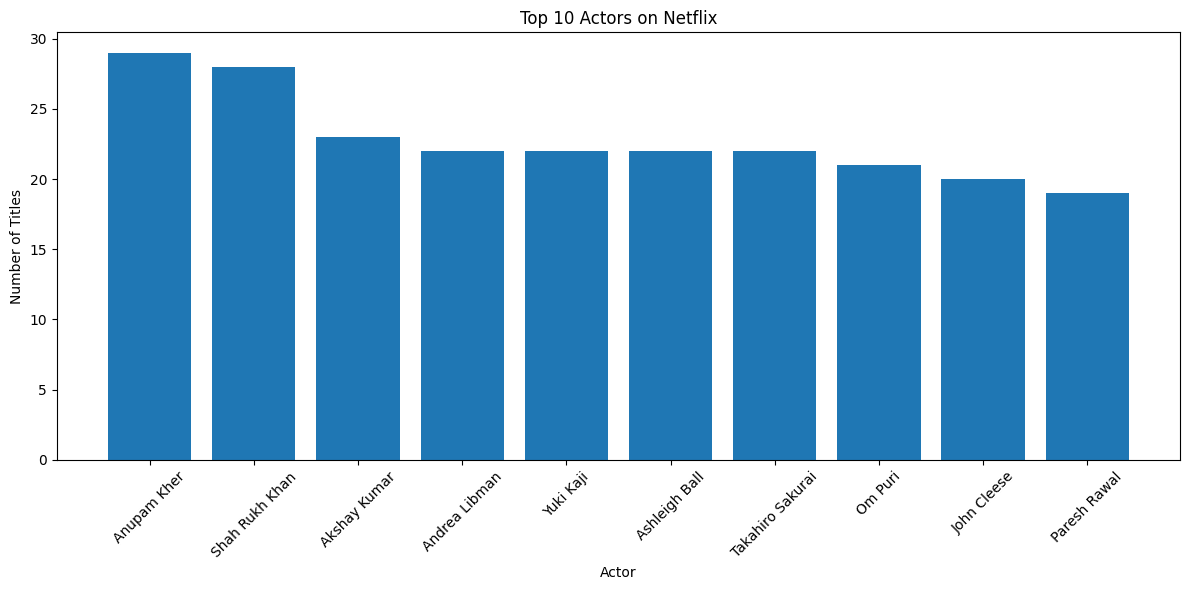

In [53]:
plt.figure(figsize=(12,6))
plt.bar(actor_count.index, actor_count.values)
plt.xlabel("Actor")
plt.ylabel("Number of Titles")
plt.title("Top 10 Actors on Netflix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
top_actor = actor_count.index[0]
top_count3 = actor_count.iloc[0]

print(f"{top_actor} is the actor who appeared most frequently on Netflix with {top_count3} titles.")

Anupam Kher is the actor who appeared most frequently on Netflix with 29 titles.


In [55]:
# Which countries produce more Movies vs TV Shows?

country_type = df.copy()
country_type['country'] = country_type['country'].str.split(',')
country_type = country_type.explode('country')
country_type['country'] = country_type['country'].str.strip()

content_country_count = (country_type.groupby(['country', 'type']).size().unstack(fill_value=0))
content_country_count

type,Movie,TV Show
country,,
Afghanistan,1,0
Albania,1,0
Argentina,52,14
Armenia,1,0
Australia,71,50
...,...,...
Vatican City,1,0
Venezuela,3,0
Vietnam,4,0


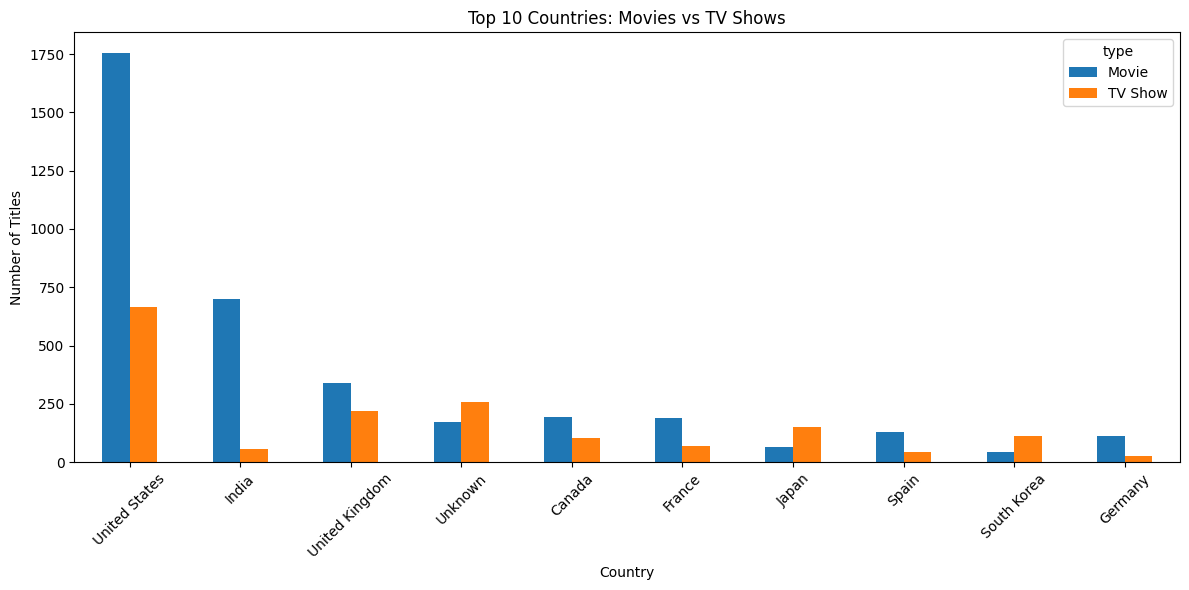

In [56]:
top10 = content_country_count.sum(axis=1).sort_values(ascending=False).head(10)

content_country_count.loc[top10.index].plot(kind='bar',figsize=(12,6))

plt.title("Top 10 Countries: Movies vs TV Shows")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
top_country = top10.index[0]
movie_count = content_country_count.loc[top_country, 'Movie']
tvshow_count = content_country_count.loc[top_country, 'TV Show']

print(f"{top_country} has the highest number of Netflix titles, with {movie_count} Movies and {tvshow_count} TV Shows.")

United States has the highest number of Netflix titles, with 1756 Movies and 665 TV Shows.


In [58]:
# Movie Duration Distribution
movie_duration=df[df['type']=='Movie']['duration']
movie_duration=movie_duration.str.replace(' min','').astype(int)
movie_duration

,duration
1,67
2,135
3,106
5,107
6,81
...,...
5831,103
5832,84
5833,29
5834,104


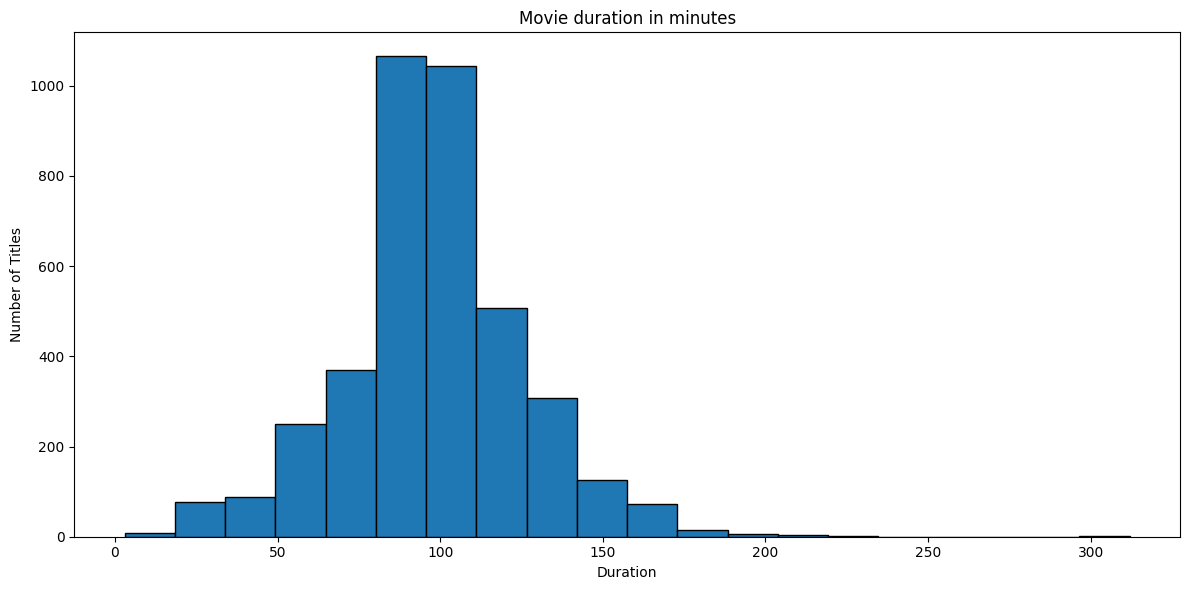

In [59]:
plt.figure(figsize=(12,6))
plt.hist(movie_duration, bins=20, edgecolor='black')

plt.title("Movie duration in minutes")
plt.xlabel("Duration")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

In [60]:
most_common_duration = movie_duration.mode()[0]

print(f"The most common movie duration on Netflix is approximately {most_common_duration} minutes.")

The most common movie duration on Netflix is approximately 90 minutes.


In [61]:
# TV Show seasons distribution
tv_show = df[df['type'] == 'TV Show'].copy()
tv_show['duration'] = (tv_show['duration'].str.replace(' Seasons', '', regex=False).str.replace(' Season', '', regex=False).astype(int))
season_count = tv_show['duration'].value_counts().sort_index()
season_count

,count
duration,
1,1259
2,298
3,157
4,60
5,46
6,21
7,21
8,16
9,7


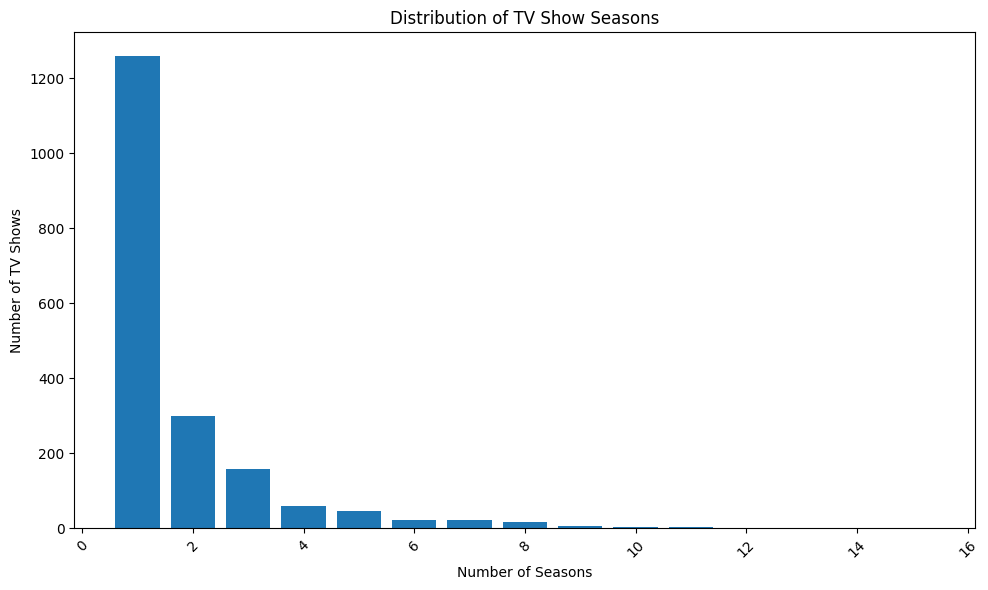

In [62]:
plt.figure(figsize=(10,6))

plt.bar(season_count.index, season_count.values)

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [63]:
# Content added to Netflix by year
years=df['date_added'].dt.year
years=years.value_counts().sort_index()
years


,count
date_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,7
2013.0,9
2014.0,19
2015.0,74
2016.0,412


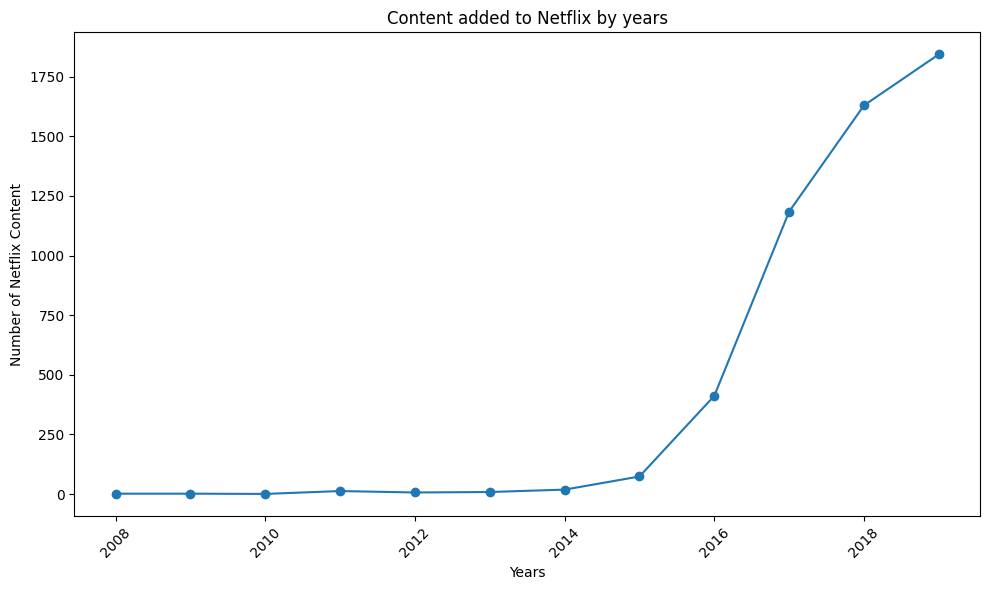

In [64]:
plt.figure(figsize=(10,6))

plt.plot(years.index, years.values, marker='o')

plt.title("Content added to Netflix by years")
plt.xlabel("Years")
plt.ylabel("Number of Netflix Content")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [65]:
print("The number of titles added to Netflix increased gradually in the early years and grew rapidly after 2015.\nThe highest number of titles was added in 2019, indicating a significant expansion of Netflix's content library.")

The number of titles added to Netflix increased gradually in the early years and grew rapidly after 2015.
The highest number of titles was added in 2019, indicating a significant expansion of Netflix's content library.


In [66]:
# Content added by month
months=df['date_added'].dt.month
months=months.value_counts().sort_index()
months


,count
date_added,
1.0,389
2.0,342
3.0,504
4.0,406
5.0,380
6.0,339
7.0,413
8.0,454
9.0,420


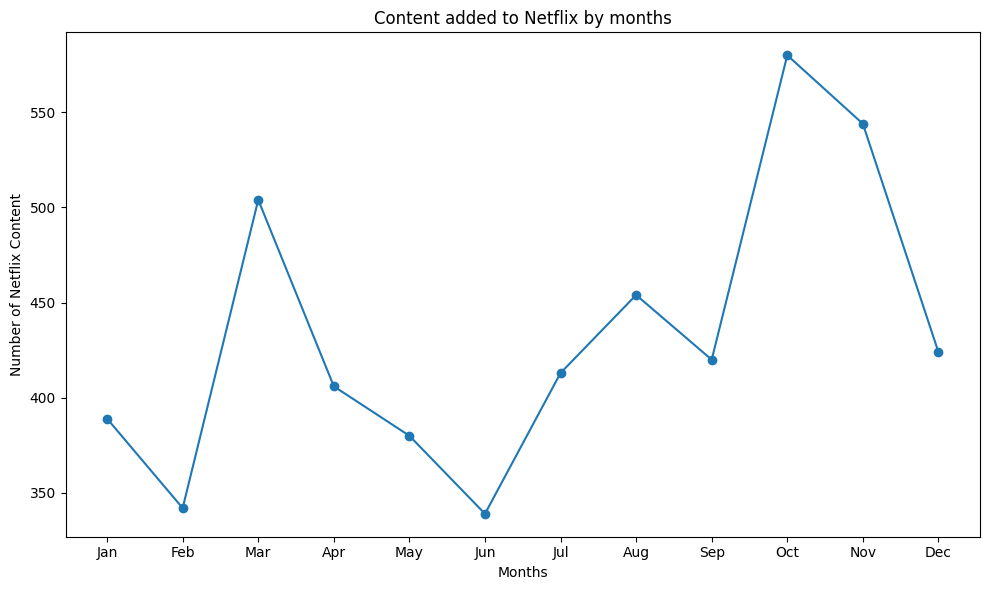

In [67]:
plt.figure(figsize=(10,6))

plt.plot(months.index, months.values, marker='o')

plt.title("Content added to Netflix by months")
plt.xlabel("Months")
plt.ylabel("Number of Netflix Content")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(months.index, month_names)
plt.tight_layout()

plt.show()

In [68]:
print("Netflix added content throughout the year, but content additions were noticeably higher during the later months,\nparticularly October, November, and December.\nFewer titles were added during the early months of the year.")

Netflix added content throughout the year, but content additions were noticeably higher during the later months,
particularly October, November, and December.
Fewer titles were added during the early months of the year.


In [76]:
# Does Netflix focus more on Movies or TV Shows in recent years?
content_count=df.groupby(['release_year','type']).size().unstack(fill_value=0)
content_count

type,Movie,TV Show
release_year,,
1925,0,1
1942,2,0
1943,3,0
1944,3,0
1945,3,0
...,...,...
2016,584,234
2017,655,273
2018,630,410


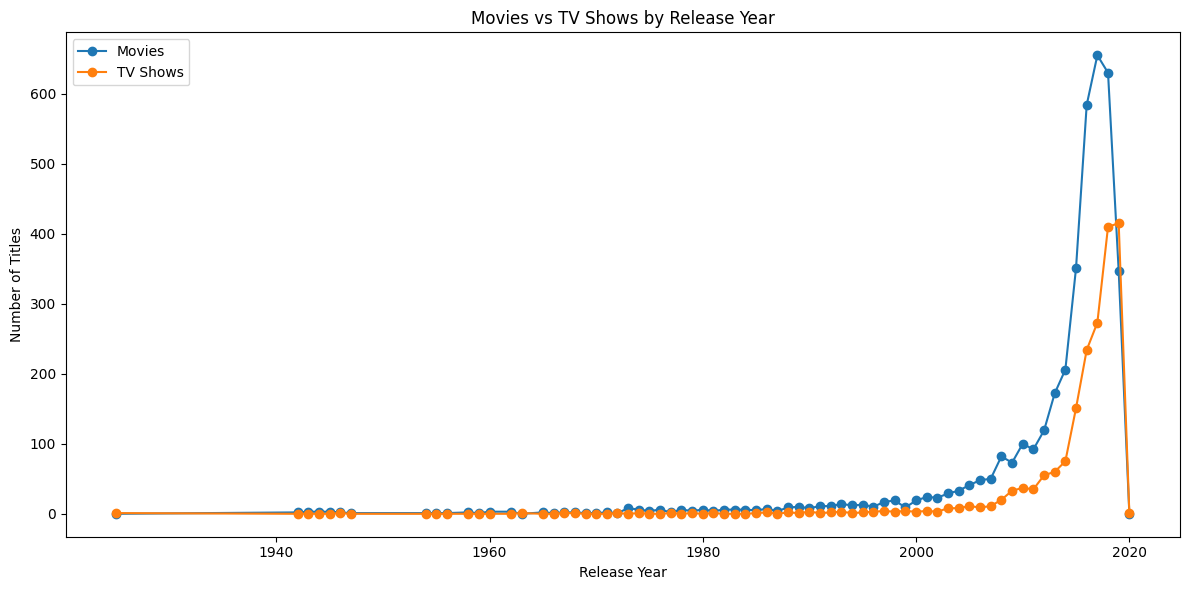

In [77]:
plt.figure(figsize=(12,6))

plt.plot(content_count.index, content_count['Movie'], marker='o', label='Movies')
plt.plot(content_count.index, content_count['TV Show'], marker='o', label='TV Shows')

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.tight_layout()
plt.show()

In [79]:
print("Netflix consistently released more Movies than TV Shows across most years.\nWhile both categories increased over time, Movies remained the dominant content type.")

Netflix consistently released more Movies than TV Shows across most years.
While both categories increased over time, Movies remained the dominant content type.


# **CONCLUSION**

- Movies make up the majority of Netflix's catalog, indicating a stronger focus on film content than TV Shows.
- The United States contributes the highest number of titles, followed by other countries such as India and the United Kingdom.
- Netflix's content library has grown significantly over the years, with a sharp increase after 2015.
- Most titles in the dataset were added to Netflix around 2019, reflecting rapid expansion during that period.
- Most TV Shows consist of a single season, while movies typically have durations between 80 and 120 minutes.
- International Movies are among the most common genres, highlighting Netflix's investment in diverse global content.

# **RECOMMENDATIONS**

- Continue investing in international and regional content to attract audiences from different countries.
- Maintain a balanced mix of Movies and TV Shows to meet diverse viewer preferences.
- Expand successful TV Show franchises by renewing high-performing series for additional seasons.
- Continue adding fresh content regularly throughout the year to improve user engagement and retention.
- Use audience preferences across genres and ratings to guide future content acquisition and production decisions.

# **EXPORT DATASET**

In [ ]:
df.to_csv("Netflix_Cleaned.csv", index=False)

In [95]:
df.shape

(5837, 12)